# Literature

<img src="https://www.researchgate.net/publication/365293694/figure/fig2/AS:11431281096592052@1668180311804/Three-types-of-geometric-edge-structure-for-kagome-lattice-nanoribbons-along-the.png" alt="Kagome Edge" width="800">

# Model

In [ ]:
from topological_insulator import Problem

structure_path = "../../topological_insulator/data/structures/"
structure_name = "kagome.json"

problem = Problem(structure_path=structure_path, structure_name=structure_name)

In [8]:
subs = ["A", "B", "C"]
for sub_label in subs:
    parser = getattr(problem.cell_parser.eigenvalues, sub_label).value
    for nn_label in subs:
        if sub_label == nn_label:
            continue
        parser["nn_hopping"][nn_label]["t_ss_sigma"] = -1

In [9]:
# NOTE: dangling_bonds = False (Type I), dangling_bonds = True (Type III)
location = "edge"
problem.setup(
    N_r = 10, # size of lattice in real space
    N_k = 500, # reciprocal space discretization
    location = location,
    BZ = "reduced",
    dangling_bonds = True
)

Building Geometry...
Geometry - Done.
Building 'Edge' Hamiltonian...
'Edge' Hamiltonian - Done.


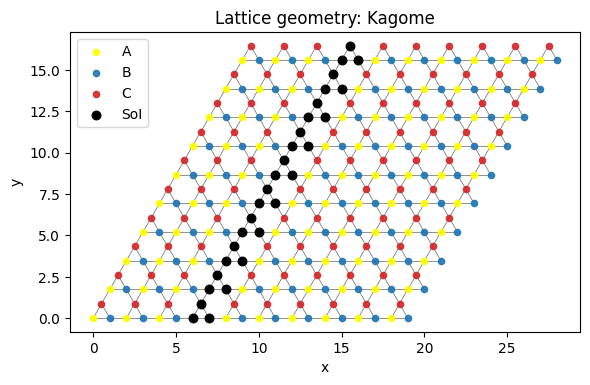

In [10]:
tb = problem.hamiltonian["edge"]["tight_binding"]
problem.geometry.plot_lattice(
    sites_of_interest=tb.sublattice_idxs
    )

In [11]:
problem.run(
    H_type="reciprocal"
)

Calculating 'Edge' eigenvalues...
'Edge' Eigenvalues - Done!


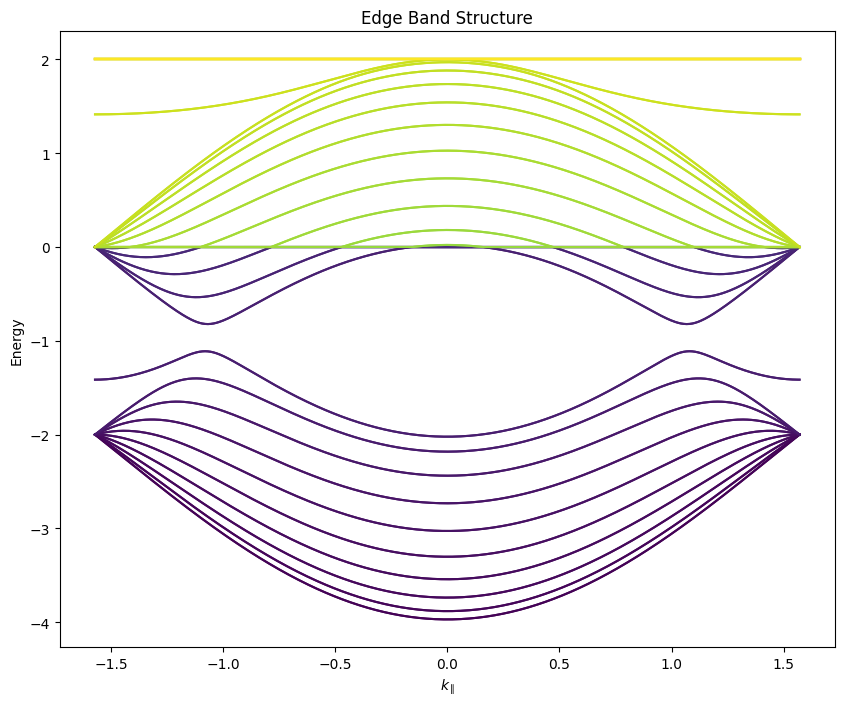

In [12]:
problem.plot(plot_type="dispersion", location=location)